In [5]:
from interface import *
from visualize import *

import random
import stim
import numpy as np

np.set_printoptions(precision=4, suppress=True, linewidth=np.inf) # type: ignore

%load_ext autoreload
%aimport interface.chip
%aimport interface.models
%aimport visualize.visualize
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Basic Chip Demo

Creating a basic l=5 x h=5 chip results in an underlying grid structure ranging from (0,0) to (2l, 2h). The chip is in a checkerboard style, where valid (x, y) coords have the property of x%2 == y%2. The chip can be visualized by using `chip.show()`

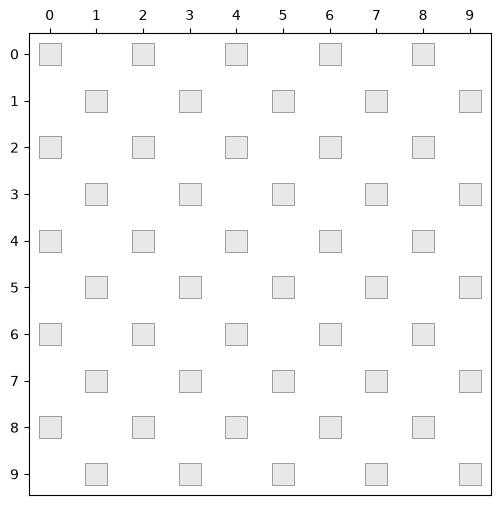

<Axes: >

In [6]:
chip = Chip(5,5)
chip.show()

In [7]:
chip.loc((0,0)).status = Status.LOGICAL
chip.loc((5,5)).status = Status.ANCILLA
print(chip.loc((0,0)))
print(chip.loc((5,5)))

Qubit(loc=(0, 0), status=Status.LOGICAL, noise=NoiseProfile(p=0.0))
Qubit(loc=(5, 5), status=Status.ANCILLA, noise=NoiseProfile(p=0.0))


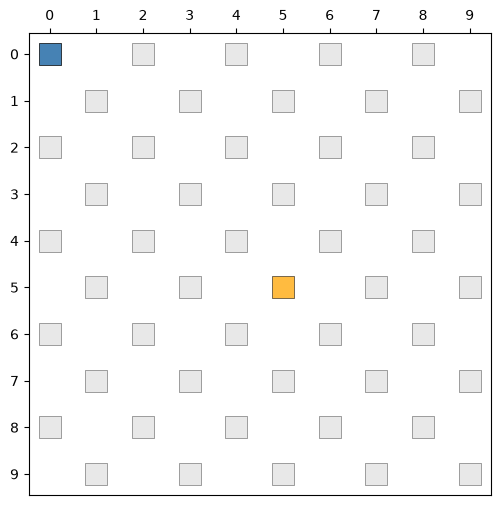

<Axes: >

In [8]:
chip.show(style=default_style)

In [9]:
chip.generate_random_noise()
chip.loc((2, 2)).noise.p = .06
print(chip.loc((2, 2)))
print(chip.noise_map)

Qubit(loc=(2, 2), status=Status.INACTIVE, noise=NoiseProfile(p=0.06))
{(0, 0): NoiseProfile(p=0.03305), (0, 2): NoiseProfile(p=0.04119), (0, 4): NoiseProfile(p=0.02585), (0, 6): NoiseProfile(p=0.03922), (0, 8): NoiseProfile(p=0.04457), (1, 1): NoiseProfile(p=0.02409), (1, 3): NoiseProfile(p=0.01572), (1, 5): NoiseProfile(p=0.04756), (1, 7): NoiseProfile(p=0.04224), (1, 9): NoiseProfile(p=0.04915), (2, 0): NoiseProfile(p=0.03466), (2, 2): NoiseProfile(p=0.06), (2, 4): NoiseProfile(p=0.02901), (2, 6): NoiseProfile(p=0.04874), (2, 8): NoiseProfile(p=0.01678), (3, 1): NoiseProfile(p=0.01982), (3, 3): NoiseProfile(p=0.01429), (3, 5): NoiseProfile(p=0.03411), (3, 7): NoiseProfile(p=0.04288), (3, 9): NoiseProfile(p=0.04996), (4, 0): NoiseProfile(p=0.01315), (4, 2): NoiseProfile(p=0.03289), (4, 4): NoiseProfile(p=0.02395), (4, 6): NoiseProfile(p=0.01292), (4, 8): NoiseProfile(p=0.02055), (5, 1): NoiseProfile(p=0.02931), (5, 3): NoiseProfile(p=0.03998), (5, 5): NoiseProfile(p=0.01457), (5, 7): 

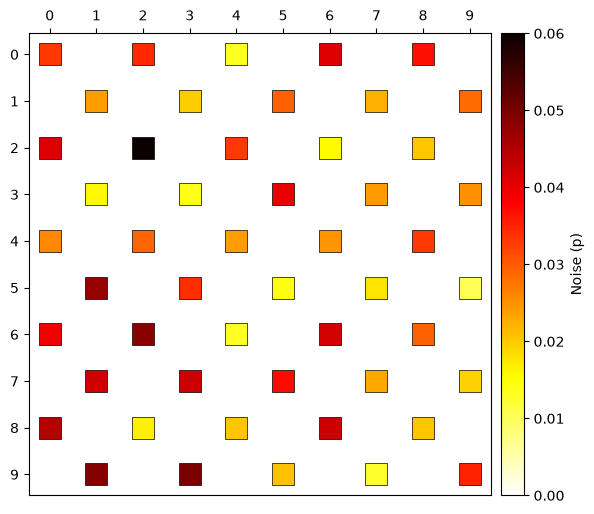

<Axes: >

In [10]:
chip.show(style=noise_heatmap_style(chip, limits =(0.0, 0.06)))

## Logical Tile Placement and Shifts

Chips are a workspace for tiles, that represent logical qubits created from STIM circuits. To create a tile, provide a STIM circuit. The size and qubit coordinates are automatically pulled from the file. Once a chip has been instantiated, you can add tiles for a given coordinate, which represents the upper leftmost qubit of the tile.

findfont: Failed to find font weight bold, now using 400.


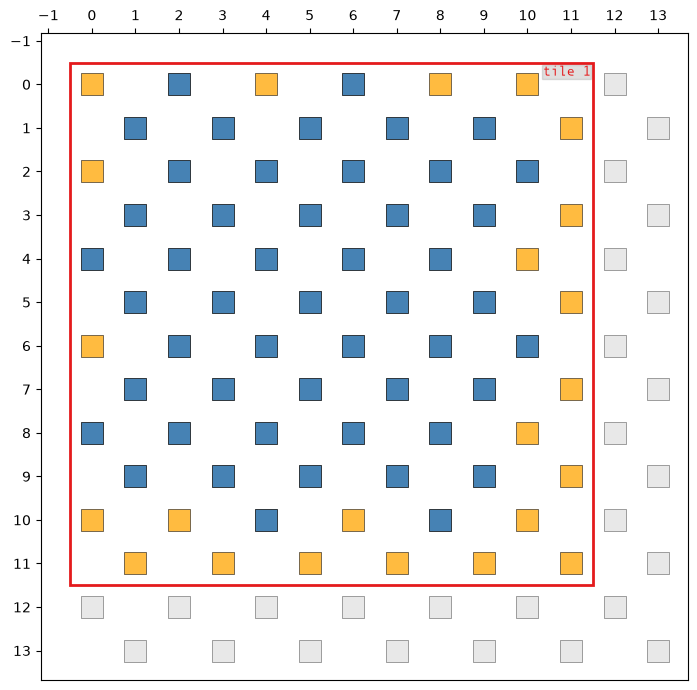

<Axes: >

In [11]:
chip = Chip(7,7)
tile = LogicalTile(circuit=stim.Circuit.generated(code_task='surface_code:rotated_memory_z', distance=5, rounds=3), tag=TileTag(distance=5))
chip.add_tile(tile, loc=(0,0))
chip.generate_random_noise()
chip.show()

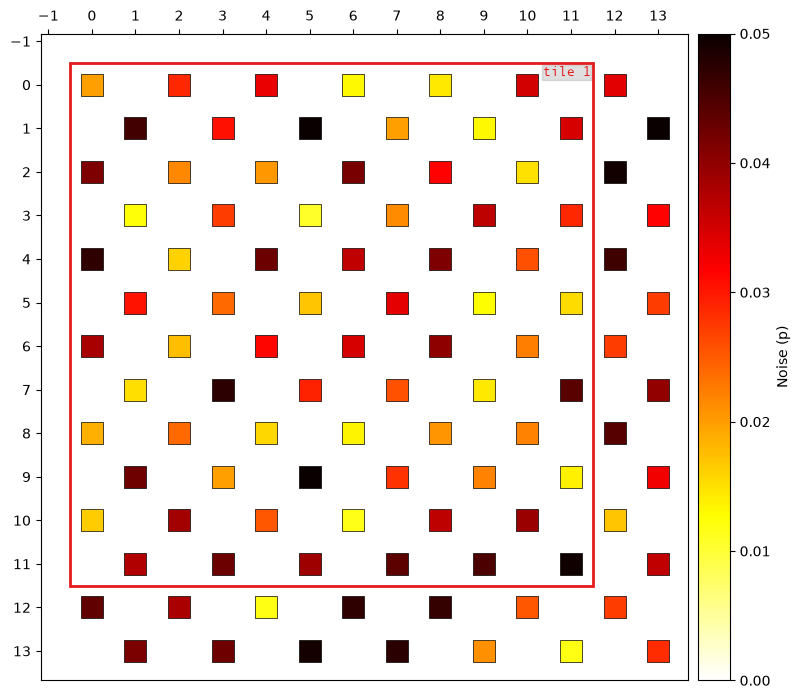

<Axes: >

In [12]:
chip.show(style=noise_heatmap_style(chip, limits=(0.0,0.05)))

In [13]:
chip.tiles[0].qubits

[Qubit(loc=(2, 0), status=Status.LOGICAL, noise=NoiseProfile(p=0.02885)),
 Qubit(loc=(0, 0), status=Status.ANCILLA, noise=NoiseProfile(p=0.01976)),
 Qubit(loc=(3, 1), status=Status.LOGICAL, noise=NoiseProfile(p=0.03064)),
 Qubit(loc=(1, 1), status=Status.LOGICAL, noise=NoiseProfile(p=0.0458)),
 Qubit(loc=(0, 2), status=Status.ANCILLA, noise=NoiseProfile(p=0.04132)),
 Qubit(loc=(2, 2), status=Status.LOGICAL, noise=NoiseProfile(p=0.02156)),
 Qubit(loc=(3, 3), status=Status.LOGICAL, noise=NoiseProfile(p=0.02726)),
 Qubit(loc=(1, 3), status=Status.LOGICAL, noise=NoiseProfile(p=0.01231)),
 Qubit(loc=(0, 4), status=Status.LOGICAL, noise=NoiseProfile(p=0.04723)),
 Qubit(loc=(2, 4), status=Status.LOGICAL, noise=NoiseProfile(p=0.01606)),
 Qubit(loc=(4, 0), status=Status.ANCILLA, noise=NoiseProfile(p=0.03329)),
 Qubit(loc=(6, 0), status=Status.LOGICAL, noise=NoiseProfile(p=0.01312)),
 Qubit(loc=(5, 1), status=Status.LOGICAL, noise=NoiseProfile(p=0.04992)),
 Qubit(loc=(7, 1), status=Status.LOGICA

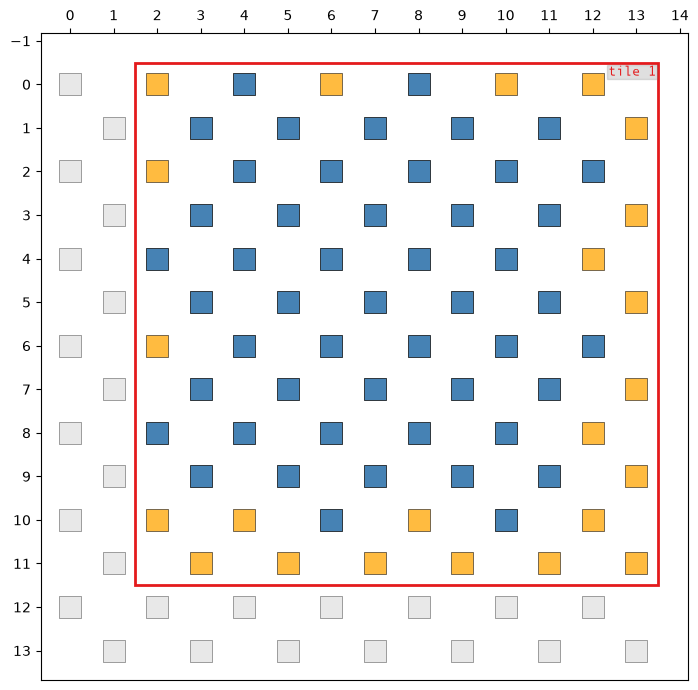

(2.0, 0.0)


In [14]:
chip.tiles[0].shift_by(2,0)
chip.show()
print(chip.tiles[0].origin)

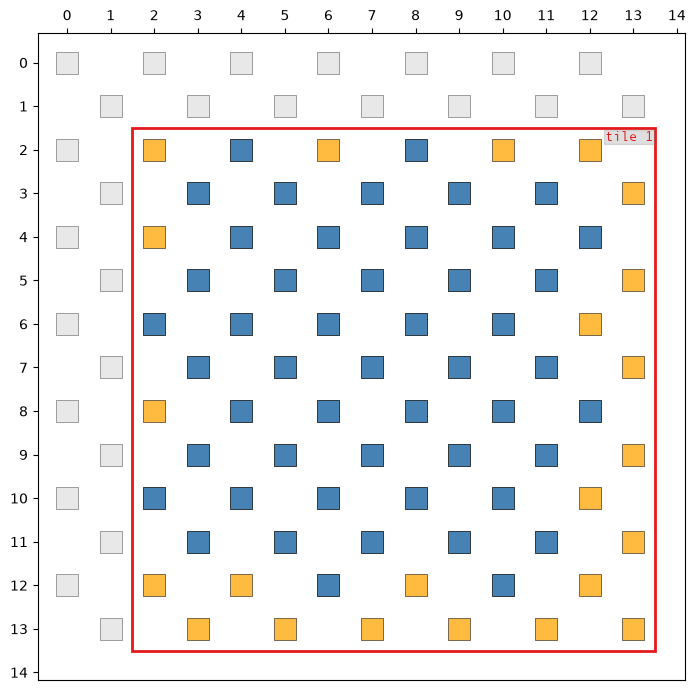

(2.0, 2.0)


In [15]:
chip.tiles[0].shift_by(0, 2)
chip.show()
print(chip.tiles[0].origin)

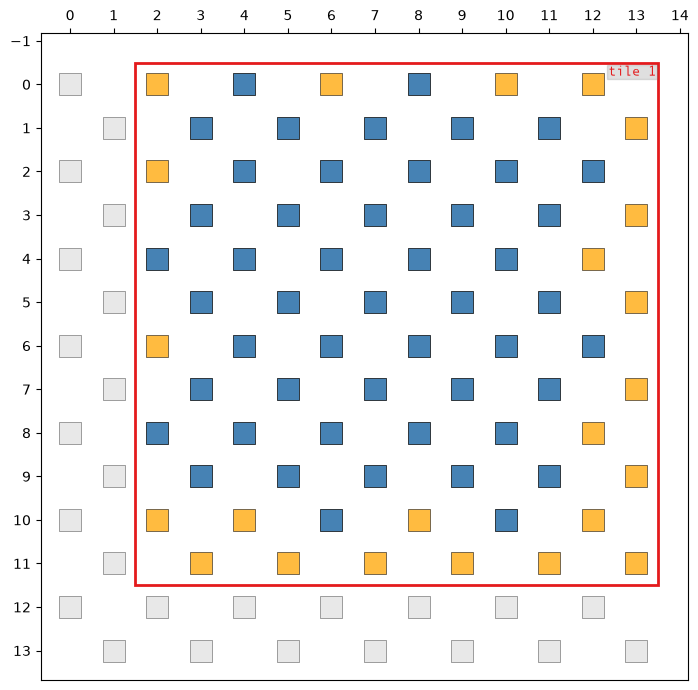

(2.0, 0.0)


In [16]:
chip.tiles[0].shift_by(0, -2)
chip.show()
print(chip.tiles[0].origin)

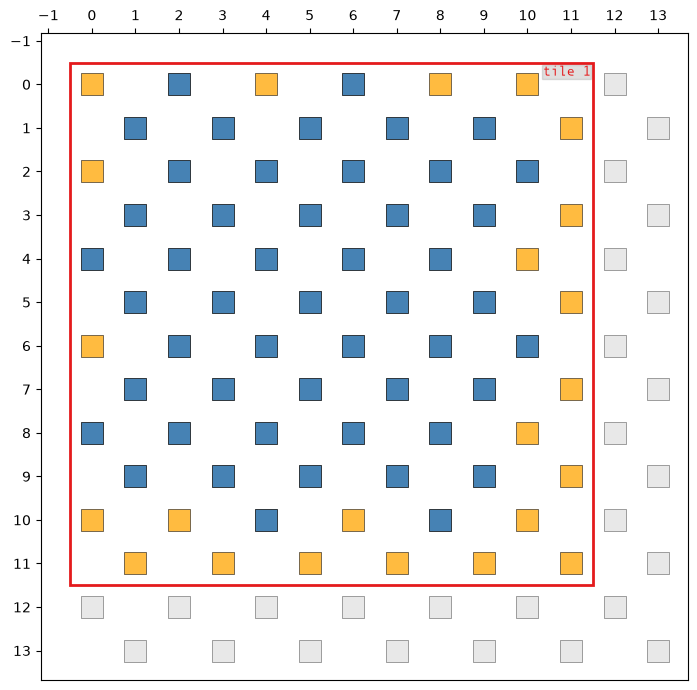

(0.0, 0.0)


In [17]:
chip.tiles[0].shift_by(-2, 0)
chip.show()
print(chip.tiles[0].origin)

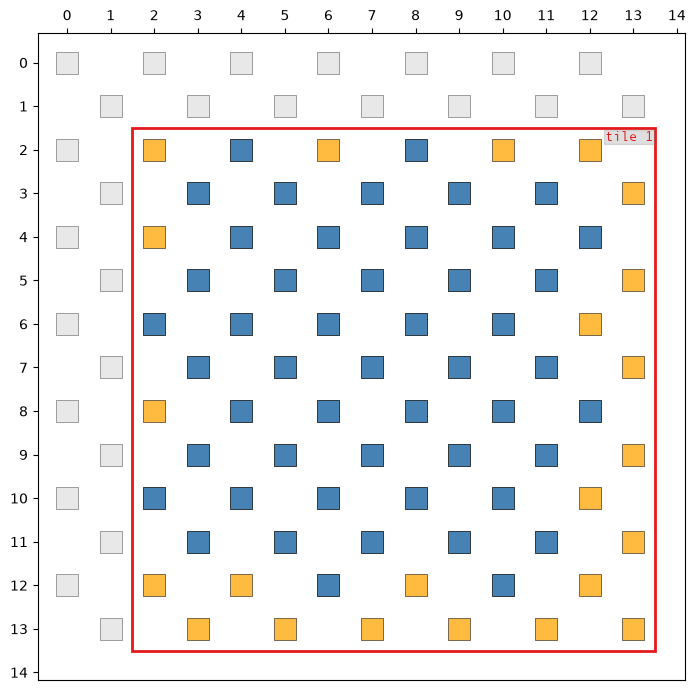

<Axes: >

In [19]:
chip.tiles[0].shift_to((2,2))
chip.show()

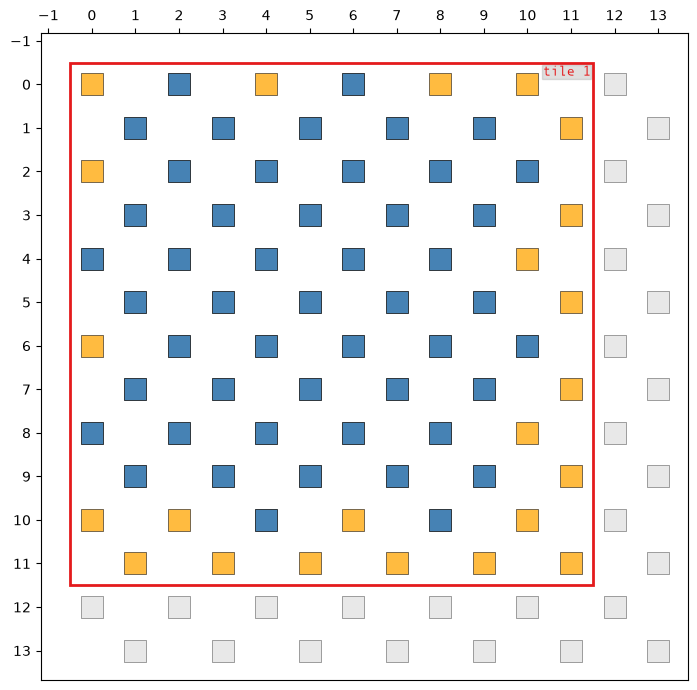

<Axes: >

In [20]:
chip.tiles[0].shift_to((0,0))
chip.show()

## Multi-Tile Demo

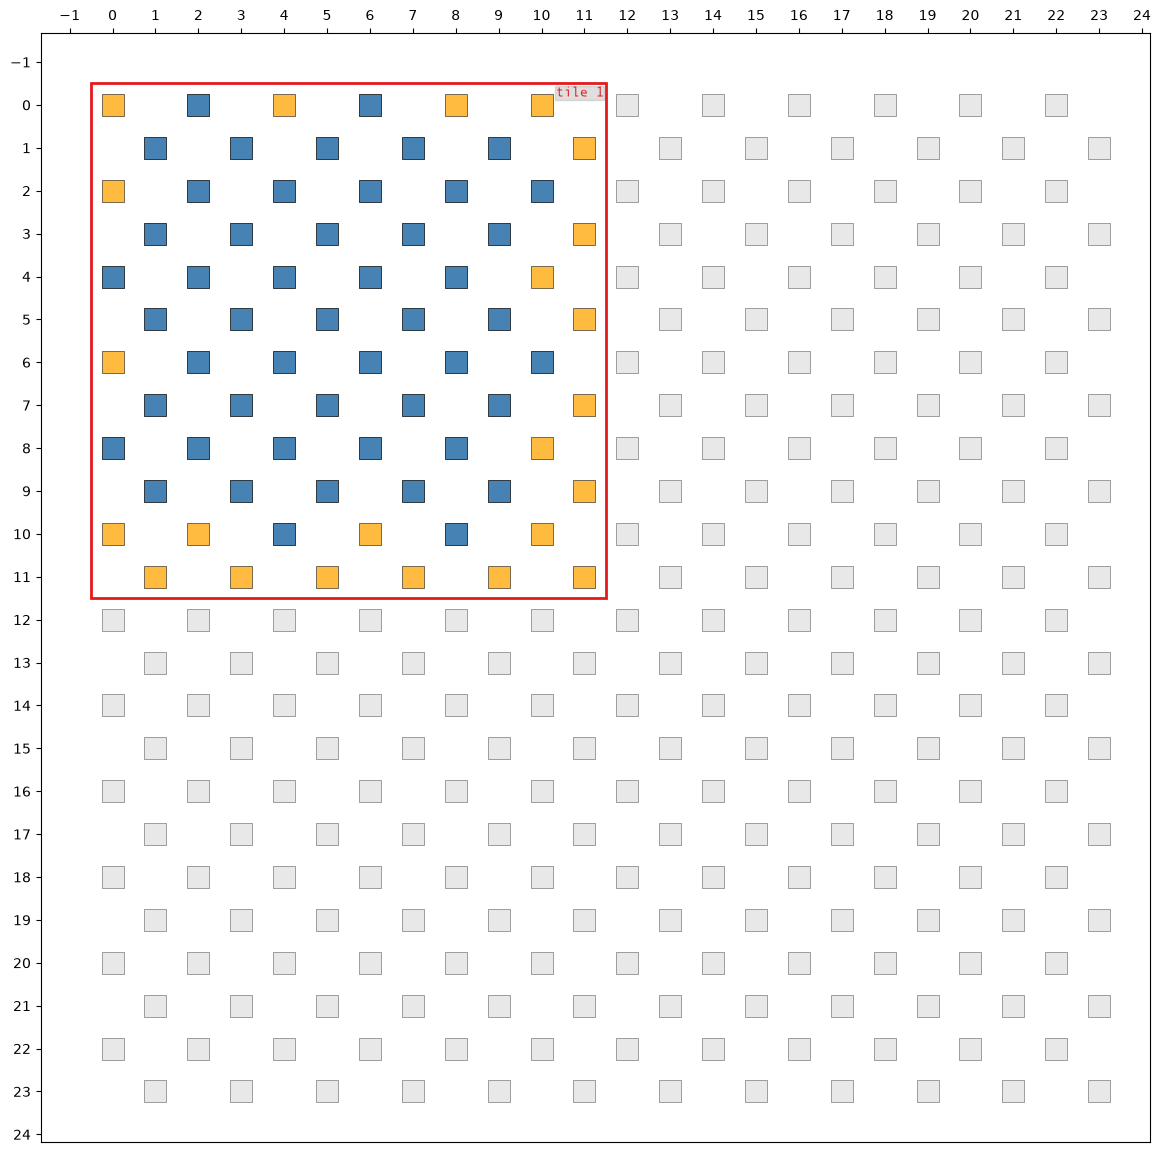

<Axes: >

In [21]:
tile3 = LogicalTile(circuit=stim.Circuit.generated(code_task='surface_code:rotated_memory_z', distance=5, rounds=3), tag=TileTag(distance=5))
chip3 = Chip(12, 12)
chip3.generate_random_noise((0.0,0.05))
chip3.add_tile(tile3,loc=(0,0))
chip3.show()

In [22]:
chip3.add_tile(tile3.copy(),loc=(12,0))
chip3.add_tile(tile3.copy(),loc=(0,12))
chip3.add_tile(tile3.copy(),loc=(12,12))

True

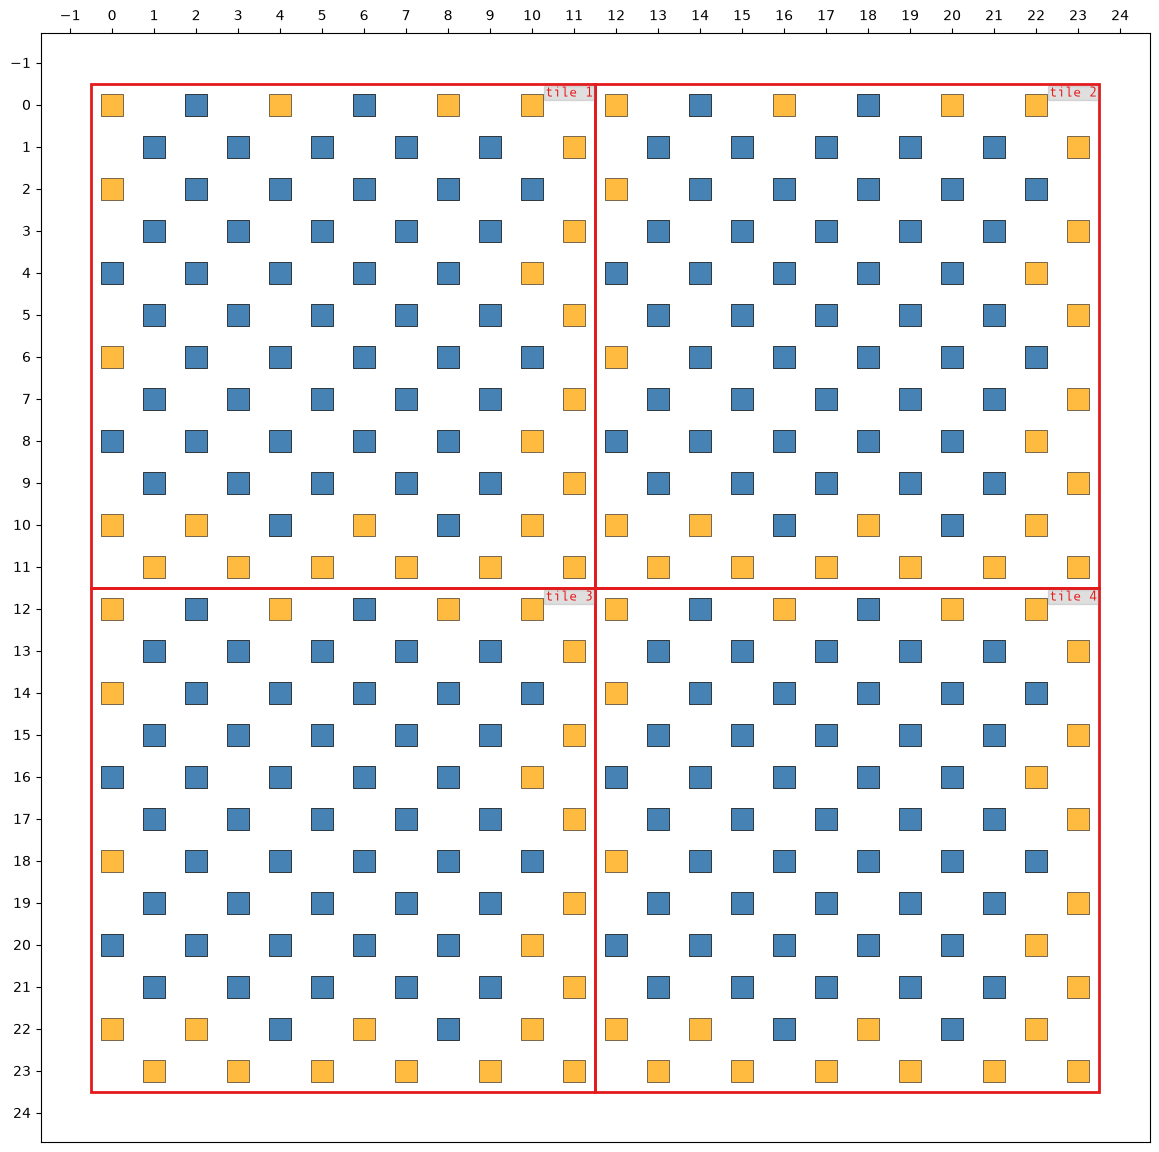

<Axes: >

In [23]:
chip3.show()

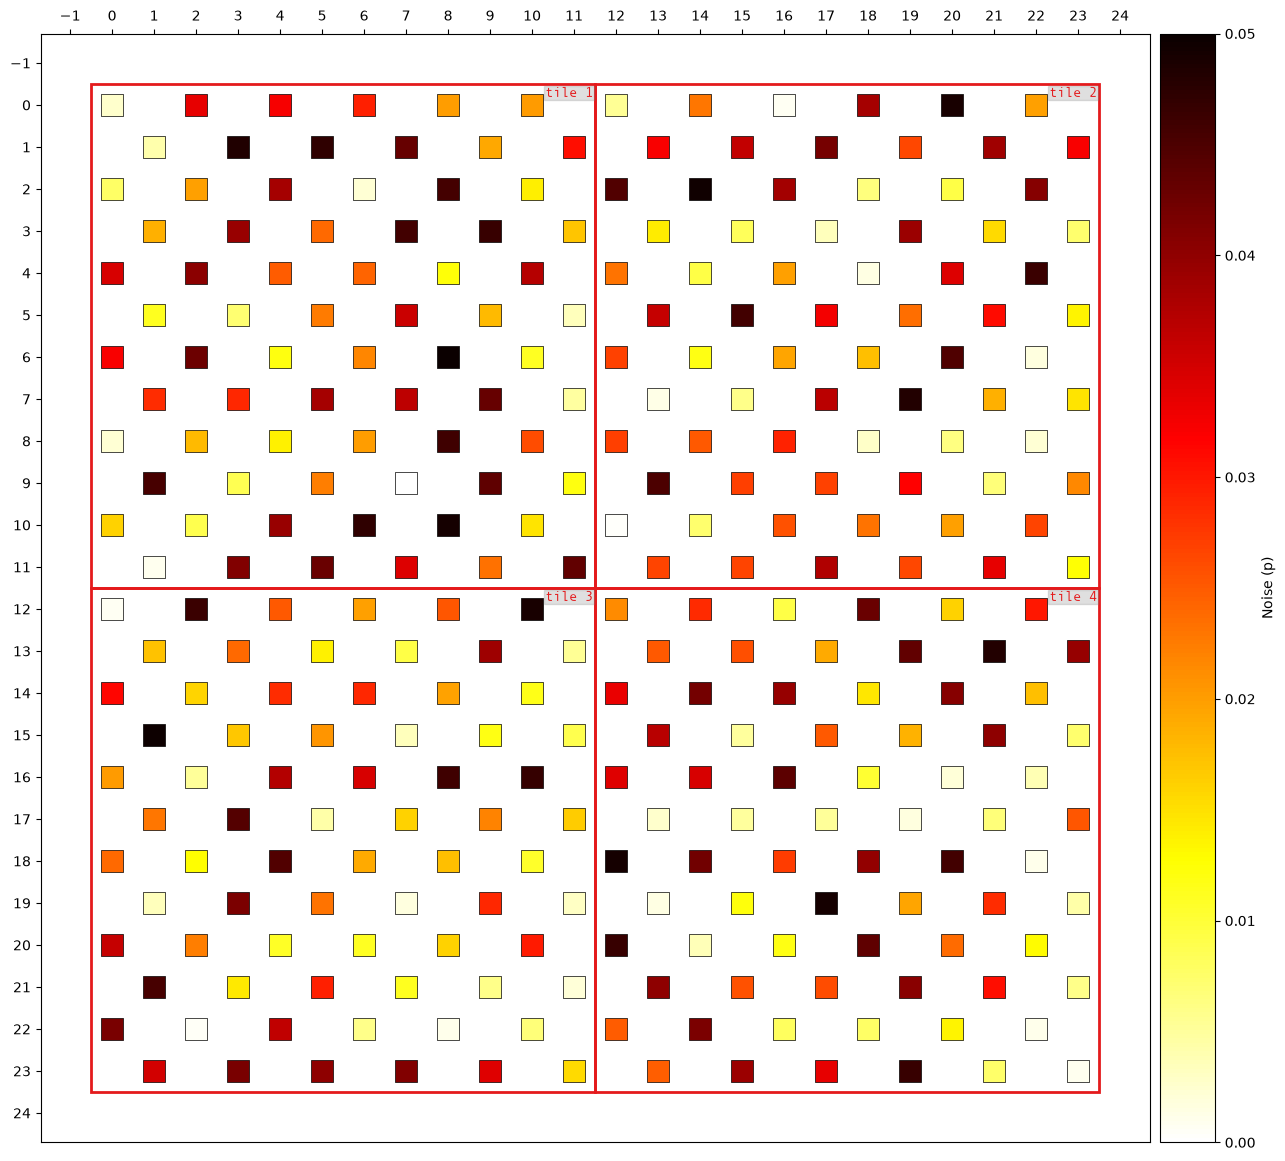

<Axes: >

In [24]:
chip3.show(style=noise_heatmap_style(chip3, limits=(0.0, 0.05)))

## Multi Tile With Various Distances

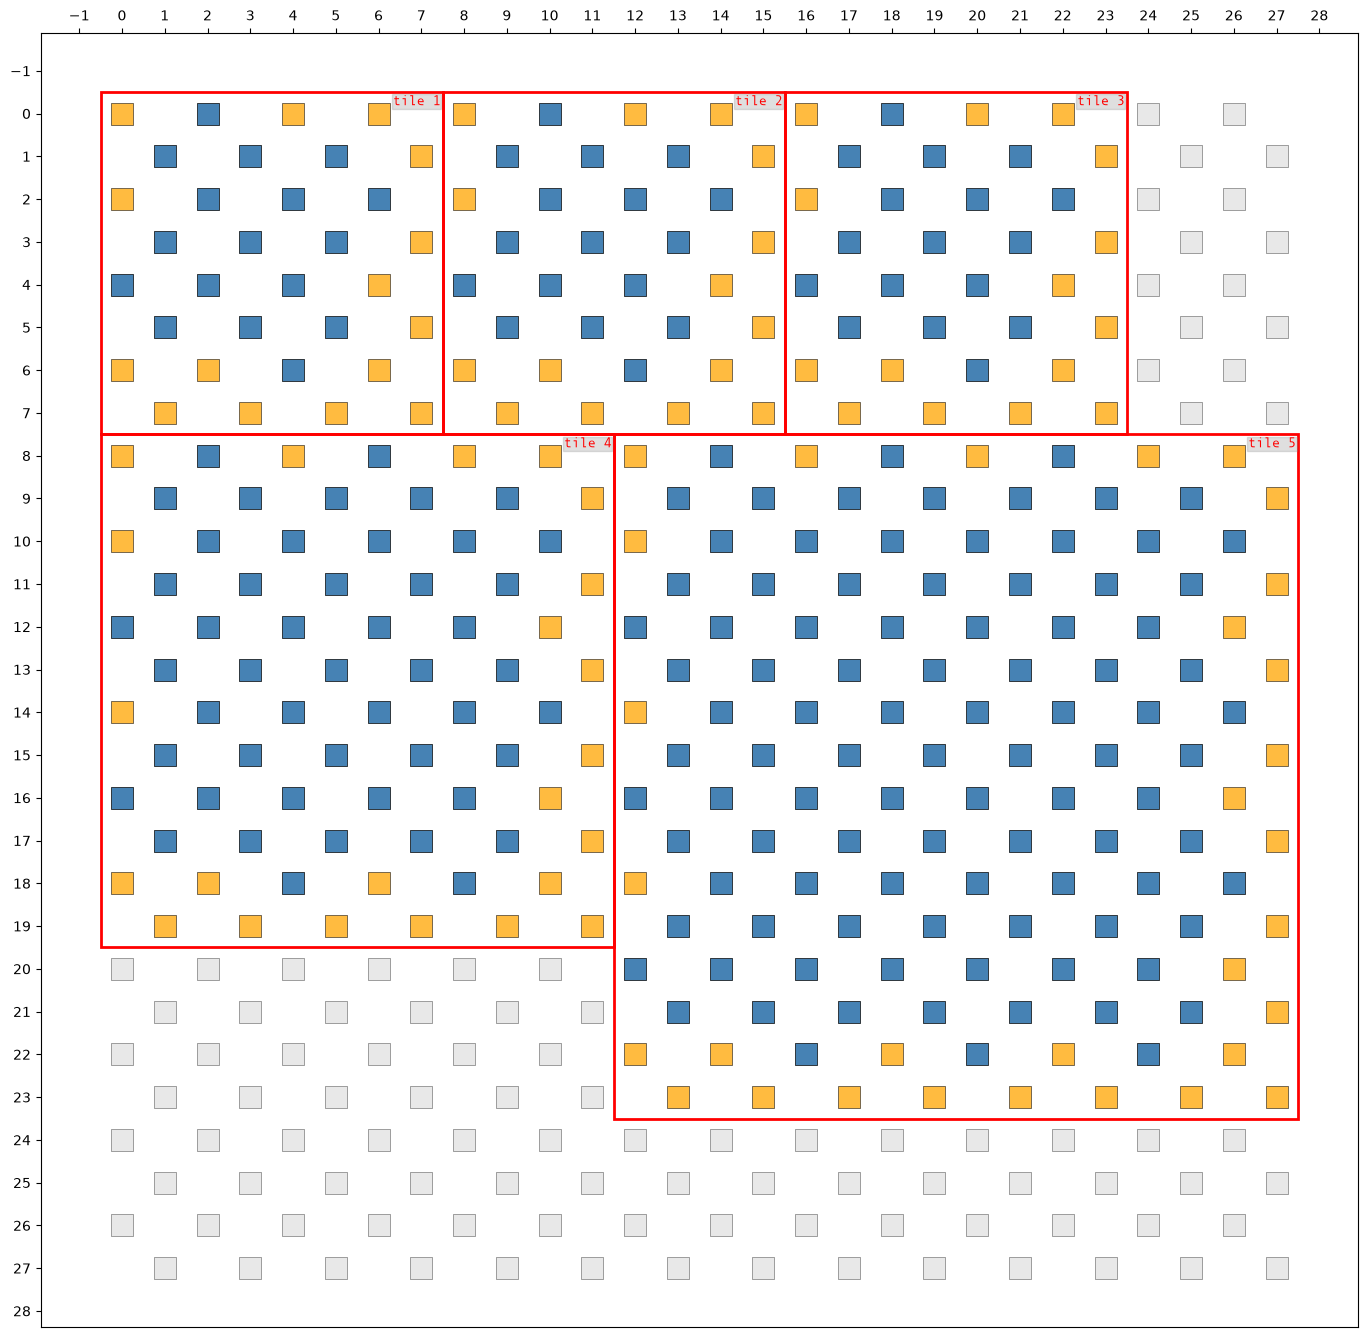

<Axes: >

In [28]:
d3Tile = LogicalTile(circuit=stim.Circuit.generated(code_task='surface_code:rotated_memory_z', distance=3, rounds=3), tag=TileTag(distance=3))
d5Tile = LogicalTile(circuit=stim.Circuit.generated(code_task='surface_code:rotated_memory_z', distance=5, rounds=3), tag=TileTag(distance=5))
d7Tile = LogicalTile(circuit=stim.Circuit.generated(code_task='surface_code:rotated_memory_z', distance=7, rounds=3), tag=TileTag(distance=7))

chip4 = Chip(14, 14)
chip4.generate_random_noise((0.0,0.05))
chip4.add_tile(d3Tile.copy(),loc=(0,0))
chip4.add_tile(d3Tile.copy(),loc=(8,0))
chip4.add_tile(d3Tile.copy(),loc=(16,0))

chip4.add_tile(d5Tile.copy(),loc=(0,8))

chip4.add_tile(d7Tile.copy(),loc=(12,8))

# chip4.add_tile(d7Tile.copy(),loc=(12,8))
chip4.show()

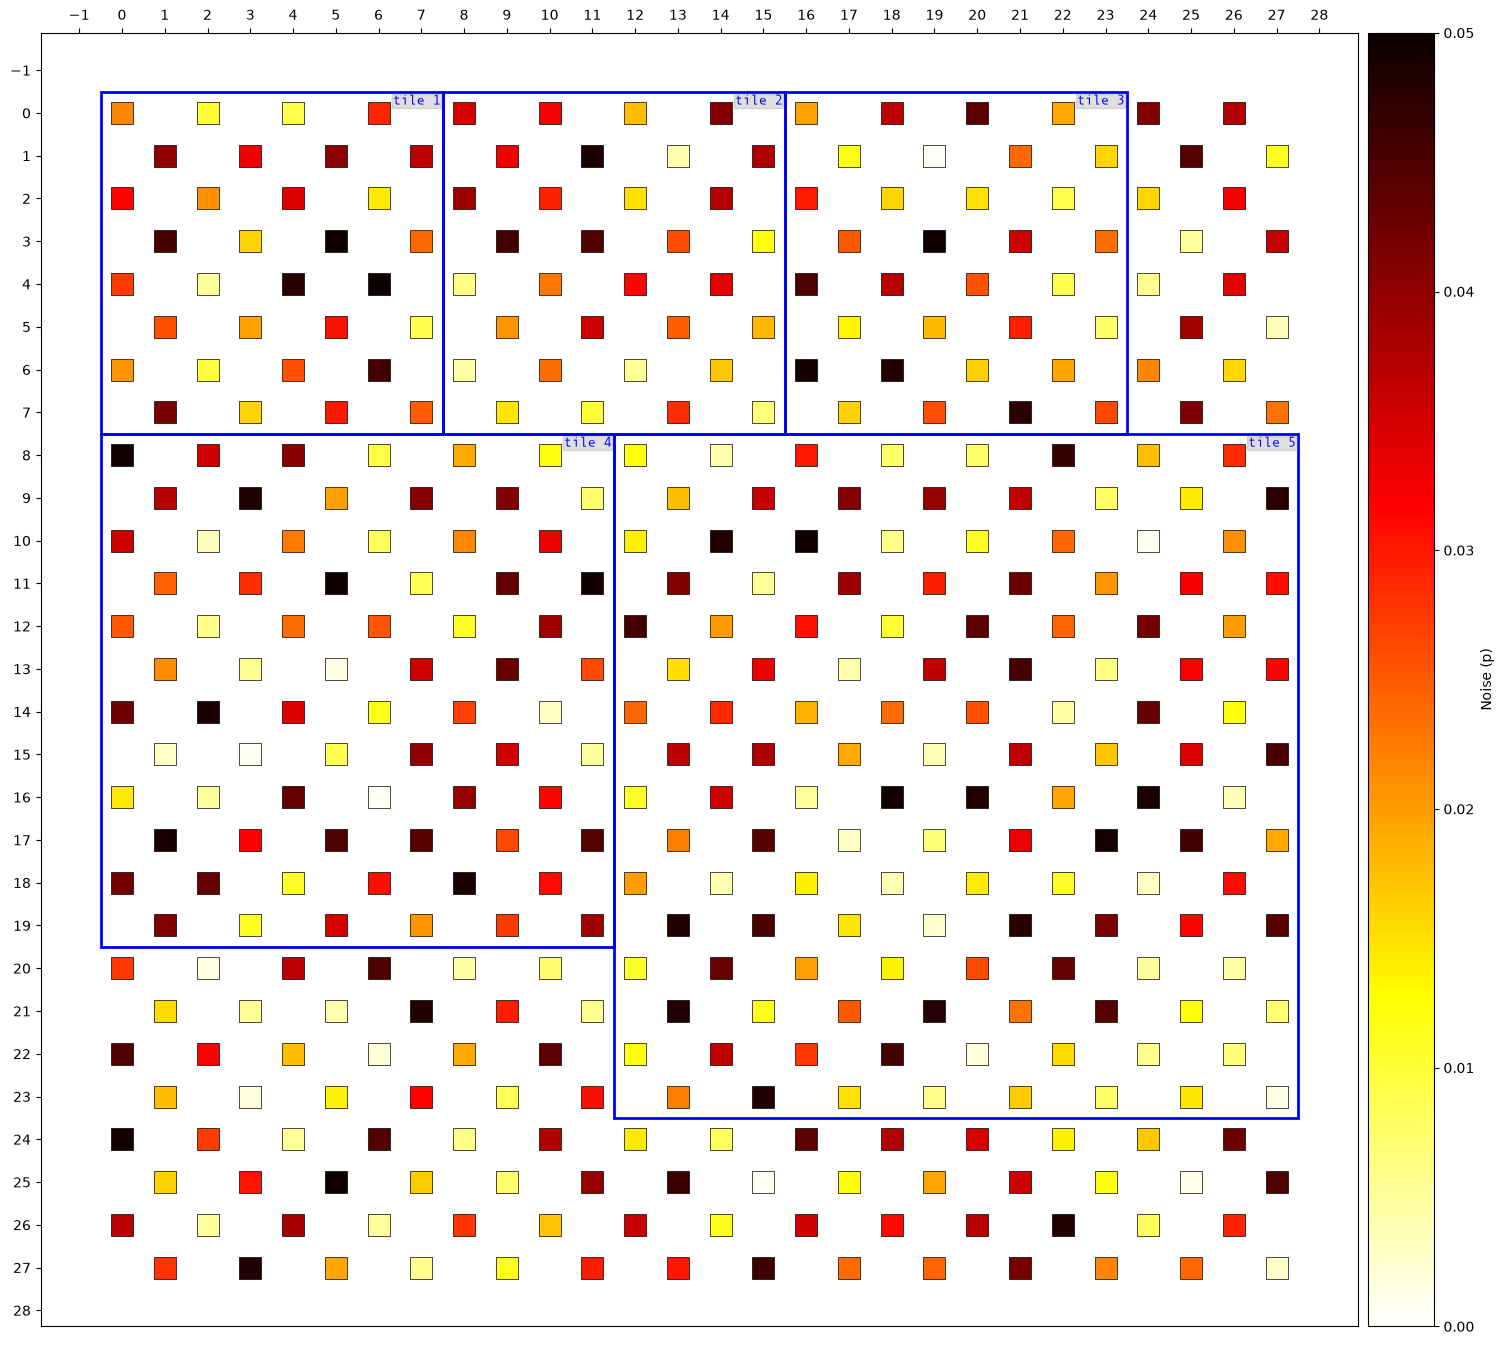

<Axes: >

In [29]:
chip4.show(noise_heatmap_style(chip4, limits=(0.0, 0.05)))